# 02 — Running Experiments

A standard qubit characterisation sequence, all using `SimulatedBackend`:

| Step | Experiment | Extracts |
|---|---|---|
| 1 | `ResonatorSpec` | Resonator frequency, κ |
| 2 | `QubitSpec` | Qubit ge transition frequency |
| 3 | `PowerRabi` | π-pulse gain |
| 4 | `T1` | Energy relaxation time |
| 5 | `Ramsey` | T2\*, detuning correction |

In [1]:
import sys; sys.path.insert(0, '../')
import numpy as np
import matplotlib.pyplot as plt

from QickworkspaceV2 import SimulatedBackend, ExperimentConfig

backend = SimulatedBackend(noise_level=0.015)
backend.activate()

config_list = [{
    "name": "Q1",
    "ch":  {"ro_ch": 0, "res_ch": 0, "qb_ch": 1},
    "res": {"res_freq_ge": 6700.0, "res_gain": 0.5, "res_length": 2.0},
    "qb":  {"qb_freq_ge": 5000.0, "pi_gain_ge": 0.5, "sigma": 0.025},
    "reps": 200, "relax_delay": 300.0, "steps": 101,
    "kappa": 4.0, "qb_kappa": 3.0,
    "wait_time_start": 0.0, "wait_time_stop": 200.0,
    "ramsey_freq": 1.5, "T2_true": 20.0, "T1_true": 50.0,
}]

cfg_all = ExperimentConfig(config_list)

[SimulatedBackend] Session activated (no hardware required)


## Helper: plot a result

In [2]:
def show(result, title='', xlabel='x', ylabel='Signal (a.u.)'):
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(result.x_axis, np.abs(result.raw_iq), lw=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    print('fit_result:', result.fit_result)
    print()

## Step 1 — Resonator Spectroscopy (`ResonatorSpec`)

Sweeps the readout tone frequency.  The circle fit (ABCD hanger model) extracts
`f0` (resonator frequency), `κ` (total linewidth), and `κ_c` (coupling rate).

C:\Users\QEL\Desktop\SQC_soc\tutorial\..\QickworkspaceV2\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


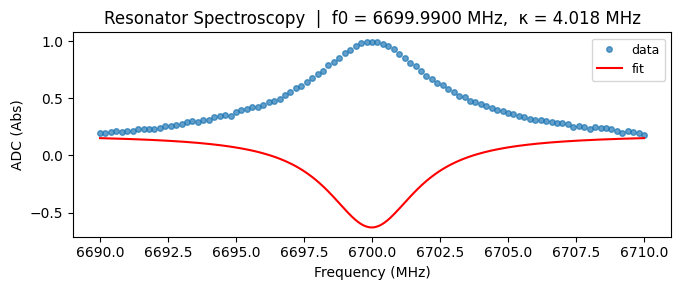

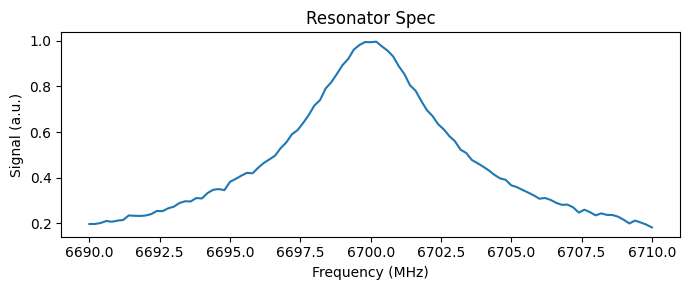

fit_result: {'f_res[MHz]': (6699.99, None), 'Qi': (1, None), 'Qc': (0, None), 'Ql': (1668, None), 'kappa_MHz': (4.0178, None)}



In [3]:
from QickworkspaceV2.experiments.resonator import ResonatorSpec

cfg = cfg_all.get_qubit('Q1')
res_result = ResonatorSpec(cfg, backend=backend).run(py_avg=5)

show(res_result, title='Resonator Spec', xlabel='Frequency (MHz)')

# Update live config with the fitted frequency
if res_result.scalar_result:
    cfg_all.update('res_freq_ge', res_result.scalar_result, q_index='Q1')

## Step 2 — Qubit Spectroscopy (`QubitSpec`)

Sweeps the qubit drive frequency while the resonator is monitored.  A Lorentzian
fit locates the ge transition frequency `f_qubit`.

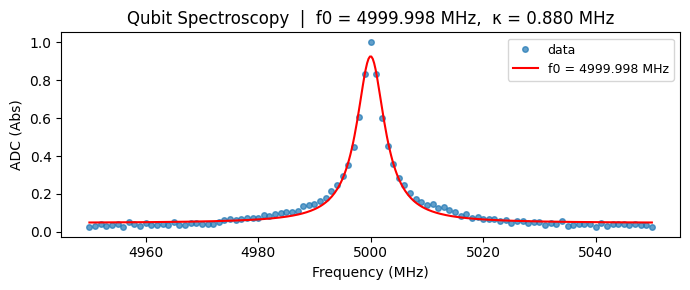

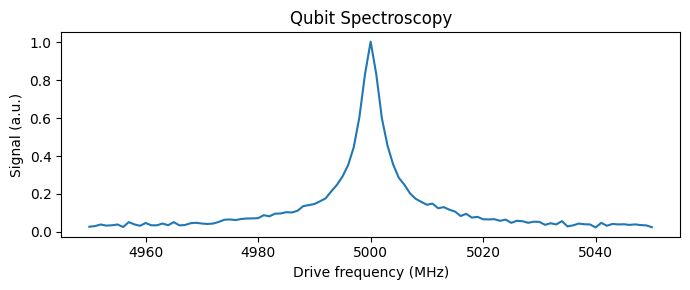

fit_result: {'f0_MHz': (4999.998169759594, 0.04674094978992327), 'linewidth_MHz': (0.8803551747396722, 0.013695922347555846), 'amplitude': (0.04642826707567203, 0.0025386340454325103)}



In [4]:
from QickworkspaceV2.experiments.qubit_ge import QubitSpec

cfg = cfg_all.get_qubit('Q1')
qs_result = QubitSpec(cfg, backend=backend).run(py_avg=5)

show(qs_result, title='Qubit Spectroscopy', xlabel='Drive frequency (MHz)')

if qs_result.scalar_result:
    cfg_all.update('qb_freq_ge', qs_result.scalar_result, q_index='Q1')

## Step 3 — Power Rabi (`PowerRabi`)

Sweeps the qubit drive amplitude.  The cosine fit finds the gain that produces
a π rotation (`pi_gain_ge`).

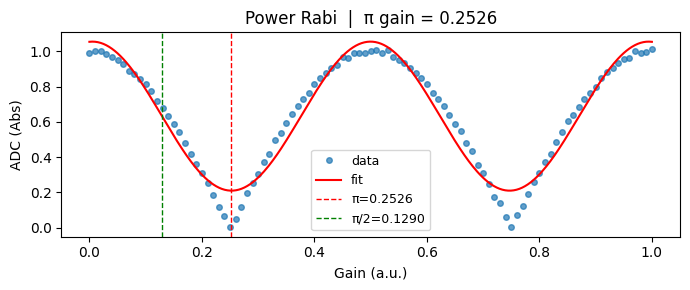

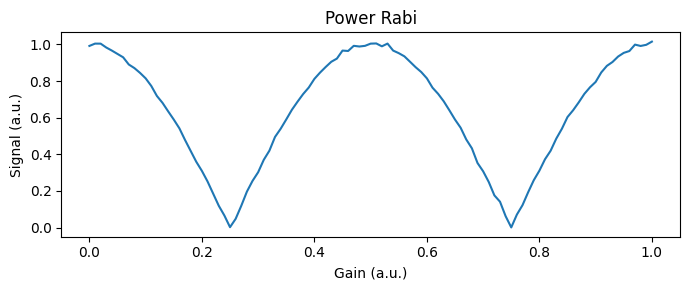

fit_result: {'pi_gain': (0.252608, None), 'pi2_gain': (0.129017, None)}



In [5]:
from QickworkspaceV2.experiments.qubit_ge import PowerRabi

cfg = cfg_all.get_qubit('Q1')
rabi_result = PowerRabi(cfg, backend=backend).run(py_avg=5)

show(rabi_result, title='Power Rabi', xlabel='Gain (a.u.)')

if rabi_result.scalar_result:
    cfg_all.update('pi_gain_ge', rabi_result.scalar_result, q_index='Q1')

## Step 4 — T1 Relaxation (`T1`)

Prepares |e⟩ with a π pulse, then waits a variable delay before readout.
Exponential decay fit yields the energy relaxation time T1.

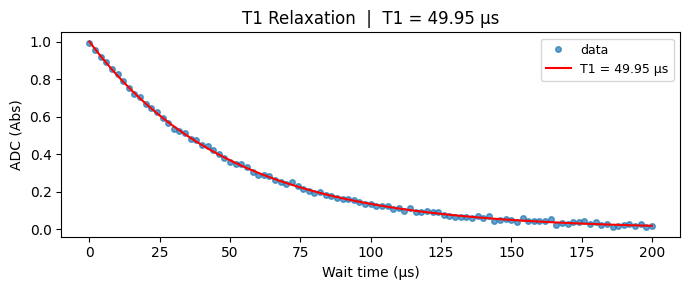

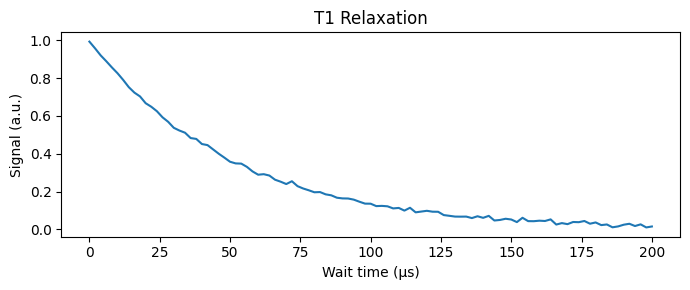

fit_result: {'T1_us': (49.94682200641839, 0.33899541388626864), 'amplitude': (0.0001893552470069807, 0.0016674897631690912), 'offset': (1.0007396382796685, 0.002667355004933565)}

T1 = 49.9 µs


In [6]:
from QickworkspaceV2.experiments.coherence import T1

cfg = cfg_all.get_qubit('Q1')
t1_result = T1(cfg, backend=backend).run(py_avg=5)

show(t1_result, title='T1 Relaxation', xlabel='Wait time (µs)')

T1_us = t1_result.scalar_result
print(f'T1 = {T1_us:.1f} µs' if T1_us else 'Fit failed')

## Step 5 — Ramsey (`Ramsey`)

Two π/2 pulses bracketing a variable free-evolution time.  The oscillation
frequency reveals any detuning from the true qubit frequency; the envelope
decay gives T2\*.

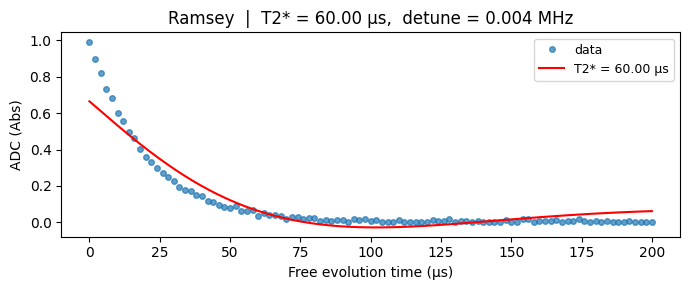

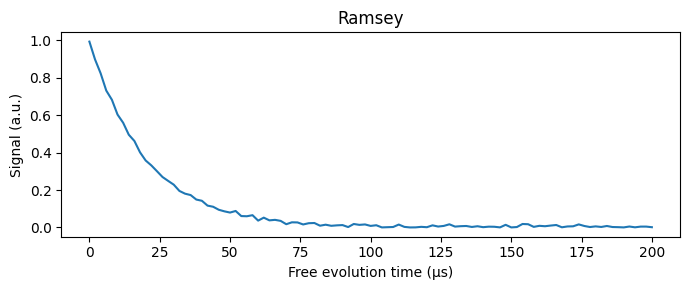

fit_result: {'T2r_us': (60.00000000006601, 13.631162775717083), 'detune_MHz': (0.0035177479327909915, 0.0009317097785044927), 'corrected_freq_MHz': (5001.498169759594, None), 'amplitude': (0.6200790871106584, 0.07130587515959728)}

T2* = 60.0 µs


In [7]:
from QickworkspaceV2.experiments.coherence import Ramsey

cfg = cfg_all.get_qubit('Q1')
ram_result = Ramsey(cfg, backend=backend).run(py_avg=5)

show(ram_result, title='Ramsey', xlabel='Free evolution time (µs)')

T2r = ram_result.scalar_result
print(f'T2* = {T2r:.1f} µs' if T2r else 'Fit failed')

## Summary

In [8]:
from QickworkspaceV2 import QualityFlag

results = [
    ('ResonatorSpec', res_result),
    ('QubitSpec',     qs_result),
    ('PowerRabi',     rabi_result),
    ('T1',            t1_result),
    ('Ramsey',        ram_result),
]

print(f'{"Experiment":<20} {"Quality":<12} {"Scalar result"}')
print('-' * 50)
for name, r in results:
    val = f'{r.scalar_result:.4f}' if r.scalar_result is not None else 'N/A'
    print(f'{name:<20} {str(r.quality.value):<12} {val}')

Experiment           Quality      Scalar result
--------------------------------------------------
ResonatorSpec        bad          6699.9900
QubitSpec            good         4999.9982
PowerRabi            good         0.2526
T1                   good         49.9468
Ramsey               good         60.0000


**Next:** [03_batch_pipeline.ipynb](03_batch_pipeline.ipynb) — composing experiments into an ordered pipeline.